# Nightlights around drug production areas

For all the drug production sites where the exact location is known, we used a 1km radius. For everything else, we used a 5km radius. 

In [2]:
import pandas as pd
drug = pd.read_excel('../../data/drug_production/Captagon Factories -- All locations 2.xlsx', skiprows=1)

In [3]:
drug['Zone'].replace({'Rural Aleppo, Afrin, Al OqaibahAl Oqaibah, the eastern enterance of the village, Al Bassoutah road': 'Rural Aleppo, Afrin, Al Oqaibah'}, inplace=True)

/var/folders/gs/_227cnyd0pq1fr817_0jbcyw0000gp/T/ipykernel_75483/4124021073.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  drug['Zone'].replace({'Rural Aleppo, Afrin, Al OqaibahAl Oqaibah, the eastern enterance of the village, Al Bassoutah road': 'Rural Aleppo, Afrin, Al Oqaibah'}, inplace=True)


In [4]:
drug['Factory_size'].replace({'large':'Large'}, inplace=True)

/var/folders/gs/_227cnyd0pq1fr817_0jbcyw0000gp/T/ipykernel_75483/737705068.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  drug['Factory_size'].replace({'large':'Large'}, inplace=True)


In [5]:
exact_locations = list(drug[drug['Yes_No'].isin(['Yes'])]['Zone'])
medium_factories = list(drug[drug['Factory_size'].isin(['Medium'])]['Zone'])
large_factories = list(drug[drug['Factory_size'].isin(['Large'])]['Zone'])

In [6]:
def get_buffer(zone):
    if zone in exact_locations and zone in medium_factories:
        return 1000
    elif zone in exact_locations and zone in large_factories:
        return 1000
    elif zone not in exact_locations:
        return 5000

In [7]:
drug['buffer_radius'] = drug['Zone'].apply(lambda x: get_buffer(x))

In [12]:
# import pandas as pd
# import geopandas as gpd

# # Example: column name is "coords" and values look like "36.289023, 37.242741\t"
# clean = (
#     drug["Coordinates"]
#     .astype(str)
#     .str.replace("\t", "", regex=False)
#     .str.strip()
# )

# # If your format is: "lat, lon"
# drug[["lat", "lon"]] = clean.str.split(",", n=1, expand=True).apply(lambda s: s.str.strip()).astype(float)

# # Point(x, y) = Point(lon, lat)
# gdf = gpd.GeoDataFrame(
#     drug,
#     geometry=gpd.points_from_xy(drug["lon"], drug["lat"]),
#     crs="EPSG:4326"
# )

# # Buffer in projected CRS, then convert buffered geometry back to EPSG:4326
# utm_crs = gdf.estimate_utm_crs()
# gdf_utm = gdf.to_crs(utm_crs)
# gdf_utm["buffer"] = gdf_utm.geometry.buffer(gdf_utm["buffer_radius"])

# gdf_buffer = gdf_utm.set_geometry("buffer").copy()
# gdf_buffer = gdf_buffer.to_crs(epsg=4326)
# gdf_buffer = gdf_buffer.set_geometry("buffer").rename_geometry("geometry")

In [ ]:
# # gdf_5km = gdf_buffer_5km[["Zone", 'Address','Factory_size','Yes_No',"buffer_5km"]]
# # gdf_10km = gdf_buffer_10km[["Zone", 'Address','Factory_size','Yes_No',"buffer_10km"]]

# # # Ensure geometry is the 10km buffer polygon
# # gdf_10km = gdf_10km.set_geometry('buffer_10km').copy()
# # gdf_10km.reset_index(drop=True, inplace=True)

# # Use spatial index to check overlaps: whether each buffer intersects any other buffer
# sidx = gdf_buffer.sindex
# overlaps = []
# for i, geom in enumerate(gdf_buffer.geometry):
#     # find candidates whose bbox intersects this geometry's bbox
#     possible = list(sidx.intersection(geom.bounds))
#     # exclude self
#     possible = [j for j in possible if j != i]
#     found = False
#     for j in possible:
#         if geom.intersects(gdf_buffer.geometry.iloc[j]):
#             found = True
#             break
#     overlaps.append(found)
# gdf_buffer['overlaps_any'] = overlaps

# n_overlapping = int(gdf_buffer['overlaps_any'].sum())
# total = len(gdf_buffer)
# print(f"{n_overlapping} of {total} buffers overlap at least one other buffer.")

# # Show list of overlapping zones (if any)
# overlapping_zones = gdf_buffer.loc[gdf_buffer['overlaps_any'], 'Zone'].tolist()
# print('Zones with overlaps:', overlapping_zones)

0 of 53 buffers overlap at least one other buffer.
Zones with overlaps: []


In [13]:
import geopandas as gpd
syria_adm0 = gpd.read_file('../../data/boundaries/syr_admin0.shp')
syria_adm1 = gpd.read_file('../../data/boundaries/syr_admin1.shp')

In [14]:
import h3
from shapely.geometry import Polygon, mapping
import geopandas as gpd


def polygon_to_h3_grid(polygon, resolution: int) -> gpd.GeoDataFrame:
    """
    Fill a shapely Polygon with H3 hexagons at the given resolution
    and return a GeoDataFrame of hex cell polygons.

    Parameters
    ----------
    polygon : shapely.geometry.base.BaseGeometry
        Input polygon in EPSG:4326 (lon/lat).
    resolution : int
        H3 resolution (0 = coarsest, 15 = finest).

    Returns
    -------
    geopandas.GeoDataFrame
        One row per H3 cell with columns: h3_index, geometry.
    """
    geojson_geom = mapping(polygon)   # converts shapely -> GeoJSON dict
    h3_cells = h3.geo_to_cells(geojson_geom, resolution)

    hex_polygons = [
        Polygon([(lng, lat) for lat, lng in h3.cell_to_boundary(cell)])
        for cell in h3_cells
    ]

    return gpd.GeoDataFrame(
        {"h3_index": list(h3_cells)},
        geometry=hex_polygons,
        crs="EPSG:4326",
    )



In [15]:

sample_polygon = syria_adm0.geometry.iloc[0]   # Syria national boundary
h3_grid = polygon_to_h3_grid(sample_polygon, 8)

In [16]:
import pyproj

utm_crs = syria_adm0.estimate_utm_crs()
syria_h3_utm = h3_grid.to_crs(utm_crs)
syria_h3_utm.iloc[0]['geometry'].area/1000000


0.8083826535723798

## Buffers around Factories

In [31]:
# import matplotlib.pyplot as plt
# import matplotlib as mpl

# fig, ax = plt.subplots()

# plot_df = gdf_buffer.copy()
# plot_df['buffer_radius_cat'] = plot_df['buffer_radius'].map({1000: '1000', 5000: '5000'})

# # markersize applies to point geometries, so plot centroids instead of polygons
# utm_crs = plot_df.estimate_utm_crs()
# plot_points = plot_df.to_crs(utm_crs).copy()
# plot_points = plot_points.set_geometry(plot_points.geometry.centroid).to_crs(plot_df.crs)

# two_color_cmap = mpl.colors.ListedColormap(['#2b8cbe', '#ef8a62'])
# plot_points.plot(
#     column='buffer_radius_cat',
#     categorical=True,
#     markersize=50,
#     cmap=two_color_cmap,
#     legend=True,
#     legend_kwds={'title': 'Buffer radius (m)'},
#     ax=ax,
# )

# syria_adm1.boundary.plot(ax=ax, edgecolor='grey', alpha=0.5, linewidth=0.3)
# plt.suptitle('Buffer Zones around Factories')
# ax.set_axis_off()

In [17]:
import os
from pathlib import Path
from getpass import getpass
from dotenv import dotenv_values
from blackmarble import BlackMarble, Product

secrets_path = Path.home() / ".config" / "syria-economic-monitor" / "secrets.env"
secrets = dotenv_values(secrets_path)
blackmarble_token = secrets.get("BLACKMARBLE_TOKEN", "").strip()

if not blackmarble_token:
    blackmarble_token = getpass("Enter BlackMarble token (input hidden): ").strip()
    secrets_path.parent.mkdir(parents=True, exist_ok=True)
    secrets_path.write_text(f"BLACKMARBLE_TOKEN={blackmarble_token}\n")
    os.chmod(secrets_path, 0o600)

bm = BlackMarble(token=blackmarble_token)

In [18]:
from blackmarble import raster, extract

In [19]:
gdf_utm["buffer"] = gdf_utm.geometry.buffer(gdf_utm["buffer_radius"])
gdf_buffer = gdf_utm.set_geometry("buffer").copy()
gdf_buffer = gdf_buffer.to_crs(epsg=4326)
#gdf_buffer = gdf_buffer.set_geometry("buffer").rename_geometry("geometry")

In [23]:
syria_h3 = syria_h3_utm.to_crs(epsg=4326).copy()
monthly_drug_5km = extract.bm_extract(
    syria_h3,
    "VNP46A3",
pd.date_range("2023-01-01", "2026-01-01", freq="MS"),
token = blackmarble_token,
output_directory='../../data/ntl/raw/',
output_skip_if_exists=True)

OBTAINING MANIFEST...:   0%|          | 0/2 [00:00<?, ?it/s]

QUEUEING TASKS | Downloading (8.7 GB)...:   0%|          | 0/74 [00:00<?, ?file/s]

PROCESSING TASKS | Downloading (8.7 GB)...:   0%|          | 0/74 [00:00<?, ?file/s]

  0%|          | 0.00/147M [00:00<?, ?B/s]

  0%|          | 0.00/128M [00:00<?, ?B/s]

  0%|          | 0.00/120M [00:00<?, ?B/s]

COLLECTING RESULTS | Downloading (8.7 GB)...:   0%|          | 0/74 [00:00<?, ?file/s]

COLLATING TILES | Processing...:   0%|          | 0/37 [00:00<?, ?date/s]

In [28]:
monthly_drug_5km['ntl_sum'].to_csv('../../data/ntl/monthly_drug_h3_8.csv', index=True)

In [34]:
drug_gdf = gpd.GeoDataFrame(drug, geometry=gpd.points_from_xy(drug["lon"], drug["lat"]), crs="EPSG:4326")

In [38]:
drug_overlay = drug_gdf.sjoin(syria_h3, how='inner', predicate='within')

In [74]:
# import matplotlib.pyplot as plt
# fig, ax = plt.subplots(figsize=(10,10))
# drug_overlay.plot(ax=ax)
# syria_h3.plot(ax=ax)

In [103]:
ntl_drugs = monthly_drug_5km.merge(drug_overlay[['h3_index', 'Zone', 'Address', 'Factory_size', 'Yes_No', 'lat', 'lon']], on = 'h3_index', how = 'left')

In [50]:
# import pandas as pd
# for time_val in monthly_drug_5km['time'].values:
#     date_str = pd.Timestamp(time_val).strftime('%Y-%m')
#     monthly_drug_5km.sel(time=time_val)['NearNadir_Composite_Snow_Free'].rio.to_raster(
#         f'../../data/ntl/raw/monthly_raster_{date_str}.tif'
#     )

In [ ]:
# monthly_drug_5km.to_csv("../../data/ntl/drug_production_custom_buffer.csv", index=False)

In [104]:
baseline = ntl_drugs[ntl_drugs["date"] =='2024-11-01']
baseline = baseline[['ntl_sum', 'h3_index']].set_index('h3_index').to_dict()['ntl_sum']

In [105]:
ntl_drugs['baseline_ntl_sum'] = ntl_drugs['h3_index'].map(baseline)
ntl_drugs['pc_change_baseline'] = 100*(ntl_drugs['ntl_sum'] - ntl_drugs['baseline_ntl_sum'])/(ntl_drugs['baseline_ntl_sum']+1)

In [106]:
ntl_drugs['Zone'].replace({'Rural Aleppo, Afrin, Al OqaibahAl Oqaibah, the eastern enterance of the village, Al Bassoutah road': 'Rural Aleppo, Afrin, Al Oqaibah'}, inplace=True)

/var/folders/gs/_227cnyd0pq1fr817_0jbcyw0000gp/T/ipykernel_75483/3637222759.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ntl_drugs['Zone'].replace({'Rural Aleppo, Afrin, Al OqaibahAl Oqaibah, the eastern enterance of the village, Al Bassoutah road': 'Rural Aleppo, Afrin, Al Oqaibah'}, inplace=True)


In [107]:
ntl_drugs = ntl_drugs[ntl_drugs['ntl_sum']>1]

## Breaking down lights into very small grids

The country is broken down in H3 grids each of the size 0.8 sq.km. The hexagons with the factory inside it are identified as the regions of interest. 

### Identified Limitations

It was seen atht June and July of 2025 have high spikes in lights in June and July, so they were removed from the maps as months of interest. This is because the quality of observations that fed into those months of data seems faulty. We're still looking into how to best deal with this data discrepancy. 

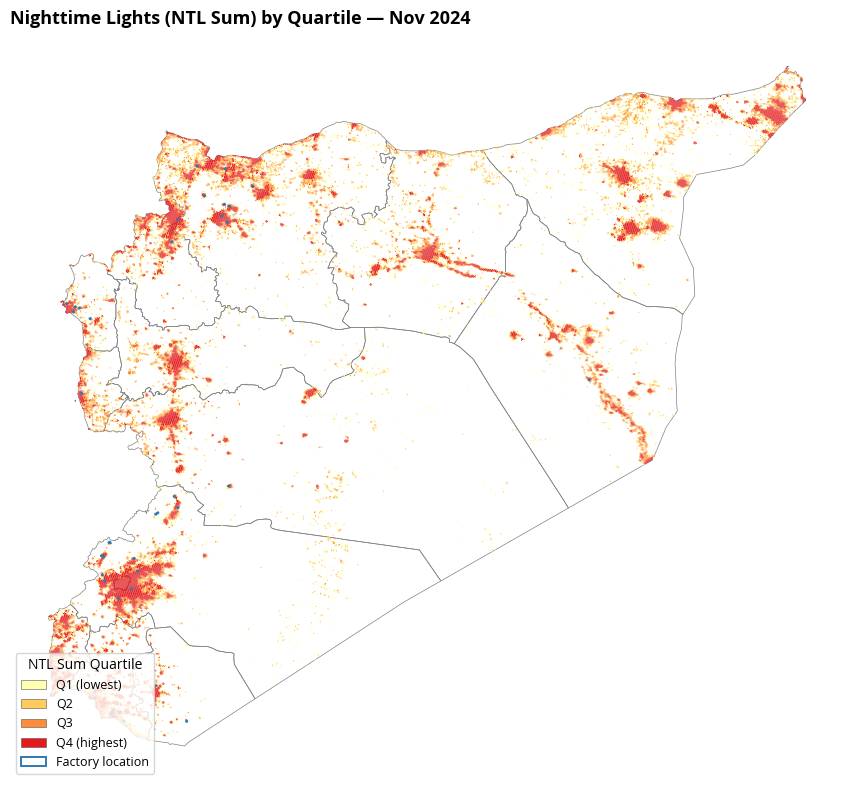

In [108]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
import pandas as pd

snapshot = ntl_drugs[ntl_drugs['date'] == '2024-11-01'].copy()

# Assign quartile labels based on ntl_sum
snapshot['ntl_quartile'] = pd.qcut(
    snapshot['ntl_sum'],
    q=4,
    labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)']
)

# Hex grids with both Zone and Address filled
has_factory = (
    snapshot['Zone'].notna() & (snapshot['Zone'].astype(str).str.strip() != '') &
    snapshot['Address'].notna() & (snapshot['Address'].astype(str).str.strip() != '')
)
snapshot_factory = snapshot[has_factory].copy()

# YlOrRd sequential — each step is clearly distinct
quartile_colors = ['#ffffb2', '#fecc5c', '#fd8d3c', '#e31a1c']
quartile_labels = ['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)']

fig, ax = plt.subplots(figsize=(10, 8))

syria_adm1.boundary.plot(ax=ax, color='grey', linewidth=0.5, zorder=1)

for label, color in zip(quartile_labels, quartile_colors):
    subset = snapshot[snapshot['ntl_quartile'] == label]
    if not subset.empty:
        subset.plot(ax=ax, color=color, linewidth=0, zorder=2)

# Overlay factory hexes with a bold outline
if not snapshot_factory.empty:
    snapshot_factory.plot(
        ax=ax,
        facecolor='none',
        edgecolor='#2c7bb6',
        linewidth=1.4,
        zorder=3,
    )

# Legend: quartile swatches + factory marker
legend_handles = [
    Patch(facecolor=c, edgecolor='#555', linewidth=0.4, label=l)
    for c, l in zip(quartile_colors, quartile_labels)
]
legend_handles.append(
    Patch(facecolor='none', edgecolor='#2c7bb6', linewidth=1.4, label='Factory location')
)
ax.legend(handles=legend_handles, title='NTL Sum Quartile', loc='lower left', frameon=True, fontsize=9)

ax.set_title('Nighttime Lights (NTL Sum) by Quartile — Nov 2024', loc='left', fontsize=13, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()


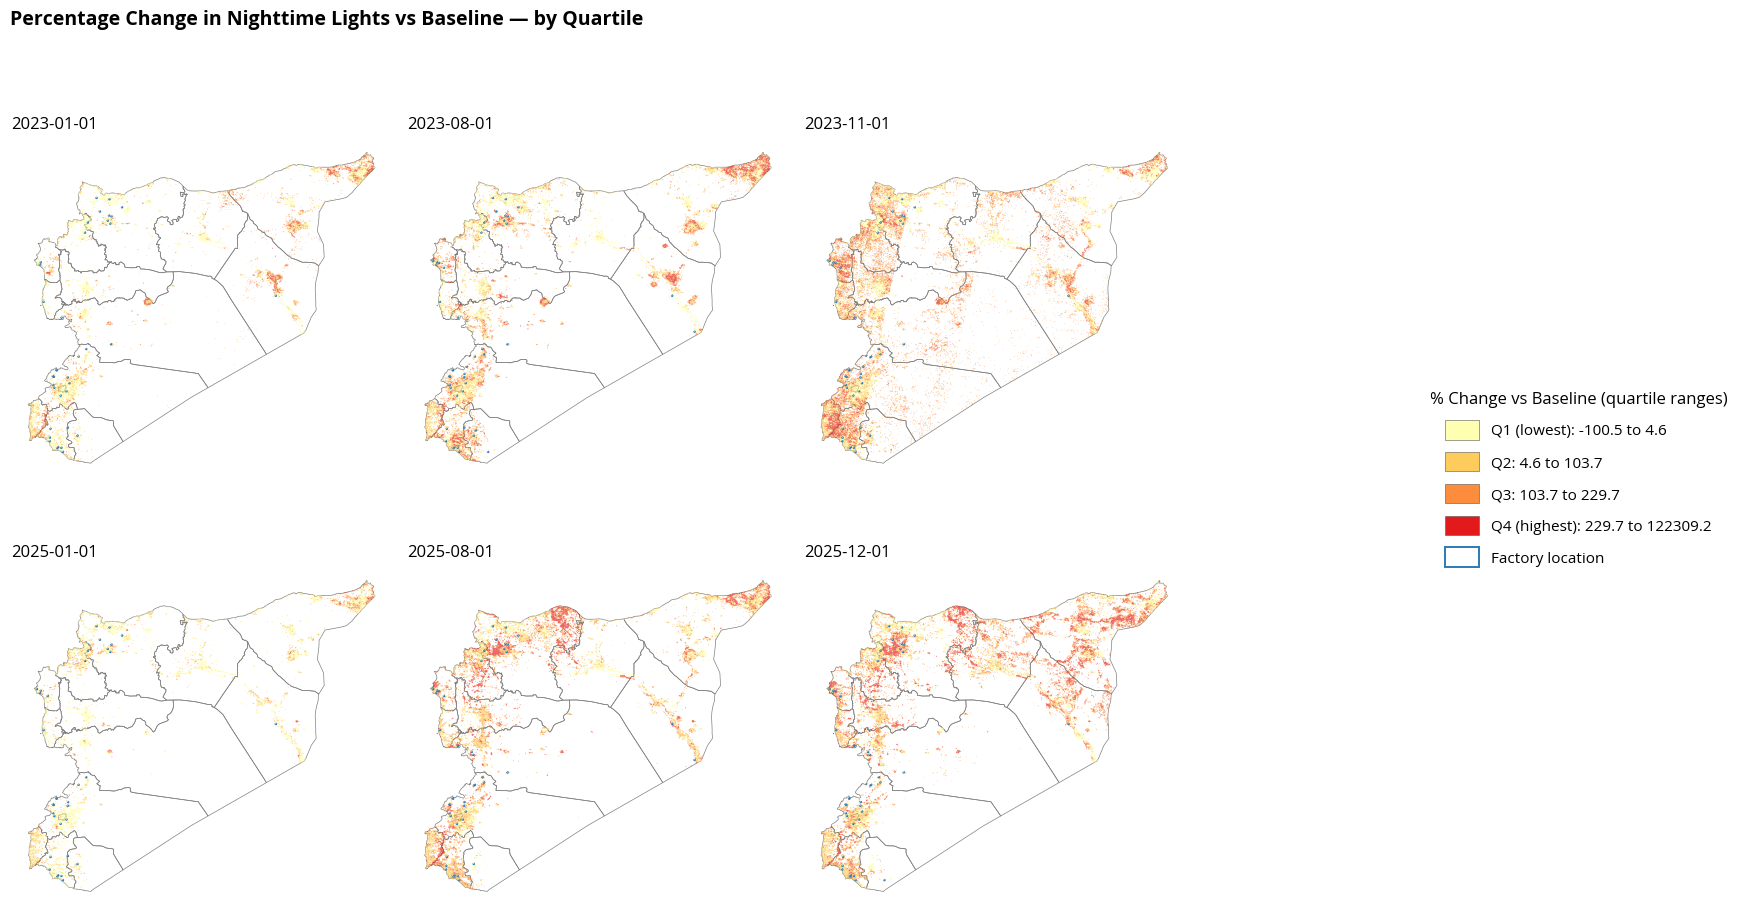

In [149]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
import pandas as pd

months_of_interest = ['2023-01-01', '2023-08-01', '2023-11-01', '2025-01-01', '2025-08-01', '2025-12-01']

# Compute global quartile breaks across all months so the scale is consistent
all_vals = ntl_drugs['pc_change_baseline'].dropna()
_, quartile_bins = pd.qcut(all_vals, q=4, retbins=True)

quartile_colors = ['#ffffb2', '#fecc5c', '#fd8d3c', '#e31a1c']
quartile_base_labels = ['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)']

# Build legend labels that include quartile ranges
quartile_labels = [
    f"{quartile_base_labels[i]}: {quartile_bins[i]:.1f} to {quartile_bins[i+1]:.1f}"
    for i in range(4)
]

fig, axes = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(14, 10))
axs = axes.flatten()

for idx, month in enumerate(months_of_interest):
    ax = axs[idx]
    subset = ntl_drugs[ntl_drugs['date'] == month].copy()

    if subset.empty:
        ax.set_title(month, loc='left')
        ax.set_axis_off()
        continue

    # Bucket pc_change_baseline using global quartile edges
    subset['quartile'] = pd.cut(
        subset['pc_change_baseline'],
        bins=quartile_bins,
        labels=quartile_labels,
        include_lowest=True,
    )

    # Factory hexes: Zone and Address both filled
    has_factory = (
        subset['Zone'].notna() & (subset['Zone'].astype(str).str.strip() != '') &
        subset['Address'].notna() & (subset['Address'].astype(str).str.strip() != '')
    )
    subset_factory = subset[has_factory]

    syria_adm1.boundary.plot(ax=ax, color='grey', linewidth=0.5, zorder=1)

    for label, color in zip(quartile_labels, quartile_colors):
        s = subset[subset['quartile'] == label]
        if not s.empty:
            s.plot(ax=ax, color=color, linewidth=0, zorder=2)

    if not subset_factory.empty:
        subset_factory.plot(
            ax=ax,
            facecolor='none',
            edgecolor='#2c7bb6',
            linewidth=1.4,
            zorder=3,
        )

    ax.set_title(month, loc='left')
    ax.grid(False)
    ax.set_axis_off()

# Shared legend
legend_handles = [
    Patch(facecolor=c, edgecolor='#555', linewidth=0.4, label=l)
    for c, l in zip(quartile_colors, quartile_labels)
]
legend_handles.append(
    Patch(facecolor='none', edgecolor='#2c7bb6', linewidth=1.4, label='Factory location')
)

fig.legend(
    handles=legend_handles,
    title='% Change vs Baseline (quartile ranges)',
    loc='center left',
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
    fontsize=11,
    title_fontsize=12,
    handlelength=2.2,
    handleheight=1.6,
    borderpad=0.8,
    labelspacing=0.8,
)

fig.suptitle(
    'Percentage Change in Nighttime Lights vs Baseline — by Quartile',
    x=0.01, y=0.97, ha='left', fontsize=14, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 0.86, 0.95])
plt.show()


## Average Nightlights in Factories

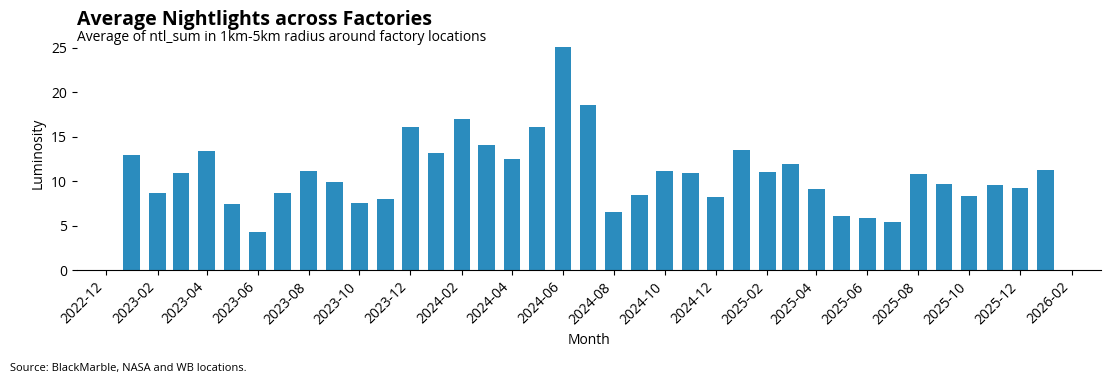

In [110]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
import pandas as pd

# prepare aggregated series
if 'monthly_drug_5km_agg' not in globals():
    monthly_drug_5km_agg = ntl_drugs.groupby('date')["ntl_sum"].mean().reset_index()

# Try to use Open Sans if available, otherwise fall back to a sensible sans
font_family = "Open Sans"
available = {f.name for f in fm.fontManager.ttflist}
if font_family in available:
    plt.rcParams['font.family'] = font_family
else:
    plt.rcParams['font.family'] = ['Open Sans', 'DejaVu Sans', 'sans-serif']

def bar_plot(ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(11,4))
    else:
        fig = ax.figure

    ax.bar(monthly_drug_5km_agg['date'], monthly_drug_5km_agg['ntl_sum'], label='NTL', color='#2b8cbe', width=20)

    ax.set_ylabel('Luminosity')
    ax.set_xlabel('Month')

    # Hide top and left box lines
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)

    # Left-aligned title
    ax.set_title('Average Nightlights across Factories', fontsize=14, weight='bold', loc='left', pad=8)

    # Subtitle placed just below the title (left-aligned)
    ax.text(
        0,
        0.96,
        'Average of ntl_sum in 1km-5km radius around factory locations',
        transform=ax.transAxes,
        fontsize=10,
        va='bottom',
        ha='left'
    )

    # Source/note at the bottom-right
    fig.text(0.21, 0.01, 'Source: BlackMarble, NASA and WB locations.', ha='right', fontsize=8)

    # Format x-axis for monthly ticks
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    return fig, ax

# draw
fig, ax = bar_plot()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid(False)
plt.show()


In [135]:
months_of_interest = ['2023-12-01', '2023-08-01', '2023-11-01', '2025-01-01', '2025-08-01', '2025-12-01']
months_of_interest_dt = pd.to_datetime(months_of_interest)
monthly_drug_5km_moi = ntl_drugs.copy()
monthly_drug_5km_moi['date'] = pd.to_datetime(monthly_drug_5km_moi['date'])
monthly_drug_5km_moi = monthly_drug_5km_moi[monthly_drug_5km_moi['date'].isin(months_of_interest_dt)].copy()

## % Change in Nightlights in each factory compared to Nov 2024

In [116]:
monthly_drug_5km_moi = monthly_drug_5km_moi[
    ~(
        (monthly_drug_5km_moi['Zone'] == 'Rural Damascus, Falita') &
        (monthly_drug_5km_moi['Yes_No'].astype(str).str.strip().str.lower() != 'yes')
    )
].copy()

monthly_drug_5km_moi = monthly_drug_5km_moi[
    ~(
        (monthly_drug_5km_moi['Zone'] == 'Rural Damascus, Sarghayah') &
        (monthly_drug_5km_moi['Yes_No'].astype(str).str.strip().str.lower() != 'yes')
    )
].copy()

In [140]:
neighbor_count_summary

"Neighbor cells per factory: Rural Damascus, Rankous (n=6), Homs, Talkalakh (n=6), Rural Aleppo, Afrin, Al Oqaibah (n=6),\n  Aleppo, Al Nairab  (n=6), Rural Damascus, Assal Al Ward  (n=6), Homs, Al Qussier  (n=6), Homs, Arjoun  (n=6), Deir\n  Ezzor, Al Mayadien  (n=6), Deir Ezzor, Al Bu Kamal  (n=6), Rural Damascus, Sarghayah (n=10), Aleppo, Al Arqoub (n=6),\n  Daraa, Nawa  (n=6), Daraa, Taiba (n=6), Daraa, Kharab Al Shahem (n=6), Rural Damascus, Maddayah (n=6), Rural Damascus,\n  Qara (n=6), Al Sawieda, Shahba (n=6), Lattakia, Eastern Al Murouj (n=6), Damascus, Al Sabourah (n=6), Rural Aleppo, Al\n  Zahraa (n=6), Rural Damascus, Al Diemas (n=6), Rural Damascus, Falita (n=11), Rural Damascus, Sidnaya.  (n=6), Rural\n  Aleppo, Azaz, Soran (n=6), Aleppo, Shikh Najjar (n=6), Daraa, Nassib (n=6), Lattakia, Kilmakho  (n=6), Tartous, Al\n  Shikh Saad (n=6), Daraa, Um Al Mayadiyen (n=6), Lattakia, Al Shelfatiyeh (n=6), Daraa, Al lajat  (n=6), Rural Idleb,\n  Tal Al Karama (n=6), Al Sawieda, A

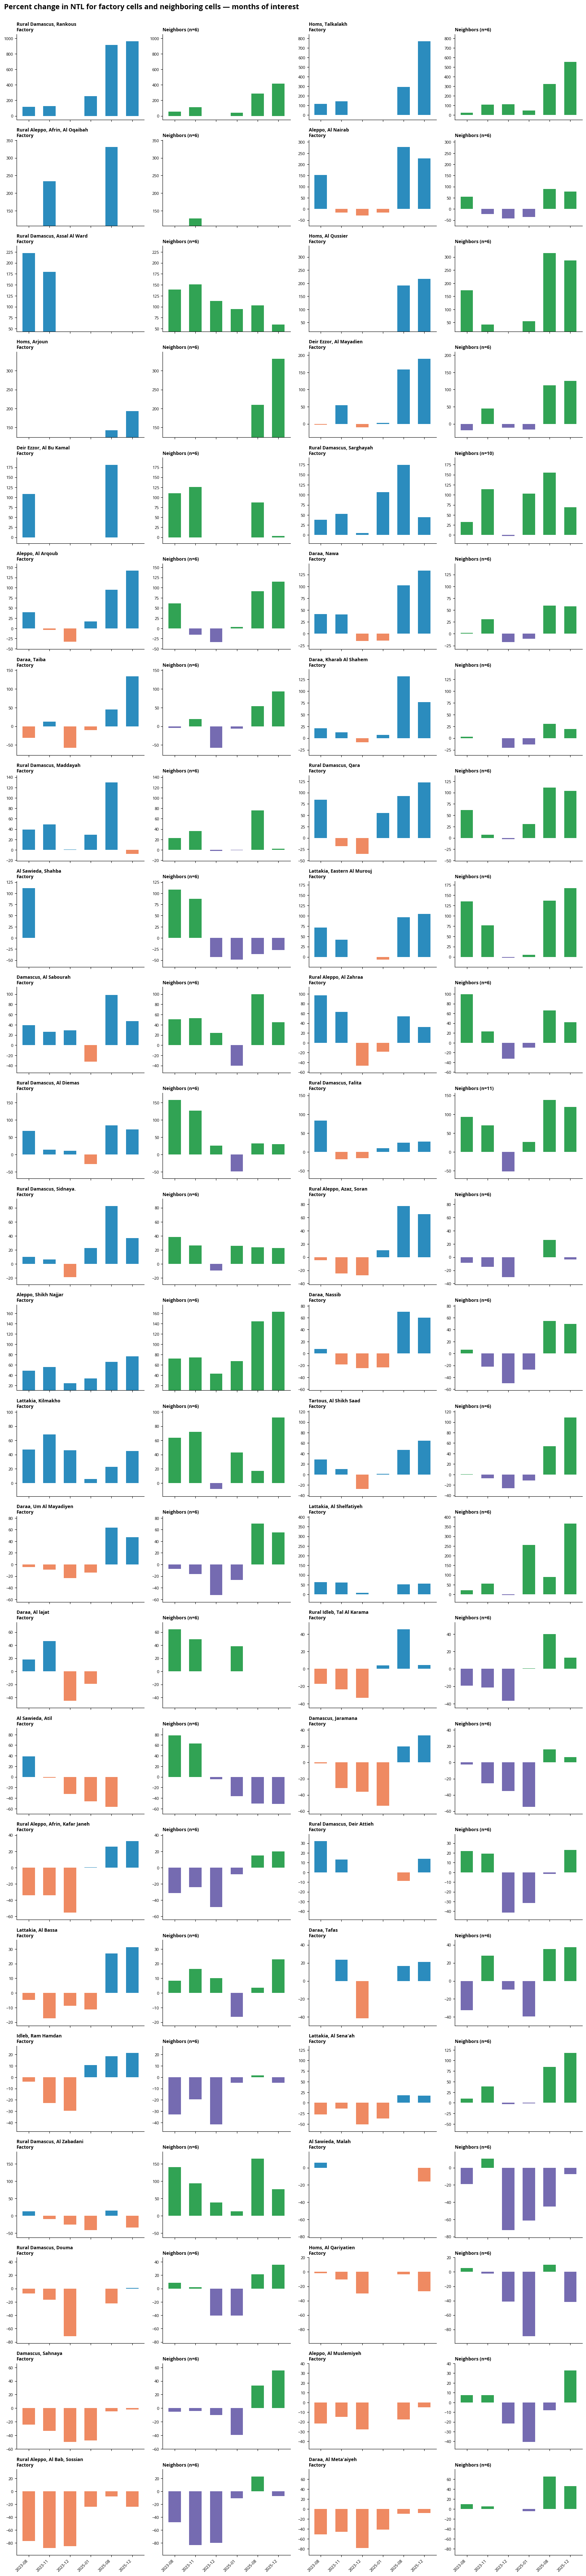

In [148]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd
import textwrap

change_col = 'pc_change_baseline'

# Use only months of interest for both factory and neighbor charts
months_dt = pd.DatetimeIndex(sorted(pd.to_datetime(months_of_interest).unique()))
months_labels = [d.strftime('%Y-%m') for d in months_dt]
positions = np.arange(len(months_dt))
pos_map = {pd.Timestamp(d): i for i, d in enumerate(months_dt)}

# Factory-level percent change, aggregated by zone and month
factory_plot_df = monthly_drug_5km_moi.copy()
factory_plot_df['date'] = pd.to_datetime(factory_plot_df['date'])
factory_plot_df = (
    factory_plot_df.groupby(['Zone', 'date'], as_index=False)[change_col]
    .mean()
)

# Neighbor percent change, aggregated by zone and month
neighbor_plot_df = factory_neighbor_links.merge(
    ntl_drugs[['h3_index', 'date', change_col]],
    on='h3_index',
    how='left'
).copy()
neighbor_plot_df['date'] = pd.to_datetime(neighbor_plot_df['date'])
neighbor_plot_df = neighbor_plot_df[
    neighbor_plot_df['date'].isin(months_dt)
].copy()
neighbor_plot_df = (
    neighbor_plot_df.groupby(['Zone', 'date'], as_index=False)[change_col]
    .mean()
)

neighbor_counts = (
    factory_neighbor_links.groupby('Zone')['h3_index']
    .nunique()
    .sort_index()
    .to_dict()
)

# Match the ordering from the original factory chart, but restricted to the months of interest
zone_max = (
    factory_plot_df.groupby('Zone')[change_col]
    .max()
    .sort_values(ascending=False)
)
zones = zone_max.index.tolist()
if not zones:
    raise RuntimeError('No zones found for the selected months of interest.')

# neighbor_count_summary = ', '.join(
#     f"{zone} (n={neighbor_counts.get(zone, 0)})" for zone in zones
# )
# neighbor_count_summary = textwrap.fill(
#     f"Neighbor cells per factory: {neighbor_count_summary}",
#     width=120,
#     break_long_words=False,
#     break_on_hyphens=False,
#     subsequent_indent='  ',
# )

n_zones = len(zones)
pair_cols = 2
zone_pairs_per_row = 2
cols = pair_cols * zone_pairs_per_row
rows = int(np.ceil(n_zones / zone_pairs_per_row))

# font: try Open Sans then fallback
font_family = 'Open Sans'
available = {f.name for f in fm.fontManager.ttflist}
if font_family in available:
    title_fp = fm.FontProperties(family=font_family, weight='bold', size=14)
    label_fp = fm.FontProperties(family=font_family, weight='bold', size=9)
    subtitle_fp = fm.FontProperties(family=font_family, size=9)
    tick_labelsize = 8
else:
    title_fp = fm.FontProperties(family='DejaVu Sans', weight='bold', size=14)
    label_fp = fm.FontProperties(family='DejaVu Sans', weight='bold', size=9)
    subtitle_fp = fm.FontProperties(family='DejaVu Sans', size=9)
    tick_labelsize = 8

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3.2), sharex=True, sharey=False)
axs = axes.flatten() if hasattr(axes, 'flatten') else [axes]

bar_width = 0.6

for idx, zone in enumerate(zones):
    pair_start = (idx // zone_pairs_per_row) * cols + (idx % zone_pairs_per_row) * pair_cols
    ax_factory = axs[pair_start]
    ax_neighbor = axs[pair_start + 1]

    zone_factory = factory_plot_df[factory_plot_df['Zone'] == zone].copy()
    zone_neighbor = neighbor_plot_df[neighbor_plot_df['Zone'] == zone].copy()

    zone_factory['pos'] = zone_factory['date'].map(lambda d: pos_map.get(pd.Timestamp(d)))
    zone_neighbor['pos'] = zone_neighbor['date'].map(lambda d: pos_map.get(pd.Timestamp(d)))

    zone_factory = zone_factory.dropna(subset=['pos'])
    zone_neighbor = zone_neighbor.dropna(subset=['pos'])

    factory_colors = ['#2b8cbe' if v >= 0 else '#ef8a62' for v in zone_factory[change_col]]
    neighbor_colors = ['#31a354' if v >= 0 else '#756bb1' for v in zone_neighbor[change_col]]

    vmin = min(zone_factory[change_col].min(), zone_neighbor[change_col].min())
    vmax = max(zone_factory[change_col].max(), zone_neighbor[change_col].max())
    padding = (vmax - vmin) * 0.1 

    ax_factory.bar(zone_factory['pos'], zone_factory[change_col], width=bar_width, color=factory_colors, align='center')
    ax_neighbor.bar(zone_neighbor['pos'], zone_neighbor[change_col], width=bar_width, color=neighbor_colors, align='center')

    ax_factory.set_title(f'{zone}\nFactory', fontproperties=label_fp, loc='left')
    ax_neighbor.set_title(f'Neighbors (n={neighbor_counts.get(zone, 0)})', fontproperties=label_fp, loc='left')

    for ax in [ax_factory, ax_neighbor]:
        ax.set_ylim(vmin - padding, vmax + padding)
        ax.set_xticks(positions)
        ax.set_xticklabels(months_labels, rotation=45, ha='right', fontsize=tick_labelsize)
        ax.tick_params(axis='y', labelsize=tick_labelsize)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(False)
        ax.set_facecolor('#ffffff')

# Hide any unused subplots
used_axes = n_zones * pair_cols
for j in range(used_axes, len(axs)):
    axs[j].set_visible(False)

fig.suptitle(
    'Percent change in NTL for factory cells and neighboring cells — months of interest',
    x=0.01, y=0.94, ha='left', fontsize=14, fontproperties=title_fp
)
# fig.text(
#     0.01, 0.962, neighbor_count_summary,
#     ha='left', va='top', fontproperties=subtitle_fp, color='#555555'
#     )
plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()


In [129]:
# Identify neighboring H3 grids around factory grids and keep the factory metadata
import h3
import pandas as pd

# One row per factory H3 cell with factory metadata
factory_sources = (
    drug_overlay[['h3_index', 'Zone', 'Address']]
    .dropna(subset=['h3_index'])
    .drop_duplicates()
    .copy()
)
factory_sources['h3_index'] = factory_sources['h3_index'].astype(str)

# Choose neighborhood radius (k=1 means immediate adjacent hexes)
k = 1

# Build neighbor-to-factory links
neighbor_records = []
for _, row in factory_sources.iterrows():
    source_cell = row['h3_index']
    neighbor_cells = set(h3.grid_disk(source_cell, k)) - {source_cell}

    for neighbor_cell in neighbor_cells:
        neighbor_records.append(
            {
                'h3_index': neighbor_cell,
                'factory_h3_index': source_cell,
                'Zone': row['Zone'],
                'Address': row['Address'],
            }
        )

factory_neighbor_links = pd.DataFrame(neighbor_records)

# Restrict to cells present in Syria grid
syria_cells = set(syria_h3['h3_index'].astype(str))
factory_neighbor_links = factory_neighbor_links[
    factory_neighbor_links['h3_index'].isin(syria_cells)
].copy()

# Aggregate factory metadata for neighbors that touch more than one factory cell
neighbor_meta = (
    factory_neighbor_links.groupby('h3_index')
    .agg(
        neighbor_of_zones=('Zone', lambda s: sorted({str(v) for v in s if pd.notna(v) and str(v).strip()})),
        neighbor_of_addresses=('Address', lambda s: sorted({str(v) for v in s if pd.notna(v) and str(v).strip()})),
        neighbor_factory_count=('factory_h3_index', 'nunique'),
    )
    .reset_index()
)

# GeoDataFrame of unique neighboring cells with factory metadata attached
factory_neighbor_h3 = syria_h3.merge(neighbor_meta, on='h3_index', how='inner').copy()
factory_neighbor_h3['is_factory_neighbor'] = True

print(f"Factory cells: {factory_sources['h3_index'].nunique()}")
print(f"Neighboring cells within k={k} (excluding factory cells): {factory_neighbor_h3['h3_index'].nunique()}")

factory_neighbor_h3.head()


Factory cells: 53
Neighboring cells within k=1 (excluding factory cells): 314


,h3_index,geometry,neighbor_of_zones,neighbor_of_addresses,neighbor_factory_count,is_factory_neighbor
0,882db3a161fffff,"POLYGON ((36.2861 32.51282, 36.28334 32.5083, ...","[Daraa, Al Meta'aiyeh]","[Al Meta'aiyeh, the western neighborhood ]",1,True
1,882dae06adfffff,"POLYGON ((37.15417 36.22839, 37.15127 36.22399...","[Aleppo, Al Arqoub]","[Al Arqoub, Naher Al Zahab street, in front of...",1,True
2,882daeb509fffff,"POLYGON ((36.93407 36.59489, 36.93116 36.59049...","[Rural Aleppo, Afrin, Kafar Janeh]","[Kafar Janeh, Moa'skar Al Talaea'a]",1,True
3,882d840087fffff,"POLYGON ((36.7411 34.15023, 36.73827 34.14576,...","[Rural Damascus, Qara]","[Qara, Around Al Shikh Ali mosque. ]",1,True
4,882dae05d1fffff,"POLYGON ((37.21149 36.1849, 37.20859 36.18051,...","[Aleppo, Al Nairab ]","[Al Nairab Camp, Behind Al Hwrani pharmacy ]",1,True
